## Parámetros

In [1]:
import os

BASE_PATH = r"D:\BigData\Proyecto"
BRONZE_DIR = os.path.join(BASE_PATH, "bronze")
SILVER_DIR = os.path.join(BASE_PATH, "silver")
GOLD_DIR   = os.path.join(BASE_PATH, "gold")

os.makedirs(BRONZE_DIR, exist_ok=True)
os.makedirs(SILVER_DIR, exist_ok=True)
os.makedirs(GOLD_DIR, exist_ok=True)

SEED = 700

print("BASE_PATH:", BASE_PATH)
print("BRONZE_DIR:", BRONZE_DIR)
print("SILVER_DIR:", SILVER_DIR)
print("GOLD_DIR:", GOLD_DIR)
print("SEED:", SEED)

BASE_PATH: D:\BigData\Proyecto
BRONZE_DIR: D:\BigData\Proyecto\bronze
SILVER_DIR: D:\BigData\Proyecto\silver
GOLD_DIR: D:\BigData\Proyecto\gold
SEED: 700


## Inicialización de Spark con Delta

In [2]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

builder = (
    SparkSession.builder
    .master("local[*]")
    .appName("Medallon_Delta")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    # AUMENTAMOS MEMORIA: 4GB para el driver (ajusta a 8g si tienes mucha RAM)
    .config("spark.driver.memory", "4g") 
    # Aumentamos el límite de tamaño de grafos de ejecución
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
)

spark = configure_spark_with_delta_pip(builder).getOrCreate()

spark.conf.set("spark.sql.sources.partitionOverwriteMode", "dynamic")
spark.conf.set("spark.databricks.delta.schema.autoMerge.enabled", "true")

print("Spark iniciado:", spark.version)

Spark iniciado: 4.0.1


## Imports

In [3]:
%run ./ClaseFeatureSelectorBDAV2.ipynb

In [4]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, mean, to_date, date_format, lit, coalesce, array, when, count, avg, sum, row_number,sqrt
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType, TimestampType

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator,MulticlassClassificationEvaluator
from pyspark.ml.classification import (DecisionTreeClassifier,RandomForestClassifier,MultilayerPerceptronClassifier,
                                       NaiveBayes, LogisticRegression,GBTClassifier,LinearSVC,FMClassifier)
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from pyspark.sql.functions import udf, col, regexp_replace, split, size, when, length, lower, trim
from pyspark.sql.types import ArrayType, DoubleType, IntegerType
import re
from pyspark.sql.functions import expr

## Bronze: lectura de fuentes

In [6]:
csv_options = {
    "header": "true",
    "inferSchema": "false", 
    "quote": "\"",          
    "escape": "\"",         
    "multiLine": "true"     
}

train_sdf = spark.read.options(**csv_options).csv(os.path.join(BRONZE_DIR, "train.csv"))
test_sdf  = spark.read.options(**csv_options).csv(os.path.join(BRONZE_DIR, "test.csv"))

# El resto de archivos suelen ser diccionarios simples, pero usaremos las mismas opciones por seguridad
state_sdf = spark.read.options(**csv_options).csv(os.path.join(BRONZE_DIR, "PetFinder-StateLabels.csv"))
color_sdf = spark.read.options(**csv_options).csv(os.path.join(BRONZE_DIR, "PetFinder-ColorLabels.csv"))
breed_sdf = spark.read.options(**csv_options).csv(os.path.join(BRONZE_DIR, "PetFinder-BreedLabels.csv"))
features_imagenes_sdf = spark.read.options(**csv_options).csv(os.path.join(BRONZE_DIR, "features_imagenes.csv"))
features_texto_sdf = spark.read.options(**csv_options).csv(os.path.join(BRONZE_DIR, "feature_texto.csv"))

for name, df in {"train": train_sdf, "test": test_sdf, "state": state_sdf, "color": color_sdf, "breed": breed_sdf, "features_imagenes": features_imagenes_sdf,"feature_texto": features_texto_sdf }.items():
    print(name, "->", df.count(), "rows")

train -> 14993 rows
test -> 3972 rows
state -> 15 rows
color -> 7 rows
breed -> 307 rows
features_imagenes -> 14993 rows
feature_texto -> 14993 rows


## Silver: transformaciones y escritura en Delta

In [7]:
breeds_ref = breed_sdf.select("BreedID", "BreedName")

train_sdf = (train_sdf
    .join(breeds_ref.withColumnRenamed("BreedName", "Breed1_Name"), 
          col("Breed1") == col("BreedID"), "left")
    .drop("BreedID", "Breed1") 
    
    .join(breeds_ref.withColumnRenamed("BreedName", "Breed2_Name"), 
          col("Breed2") == col("BreedID"), "left")
    .drop("BreedID", "Breed2")
)


test_sdf = (test_sdf
    .join(breeds_ref.withColumnRenamed("BreedName", "Breed1_Name"), 
          col("Breed1") == col("BreedID"), "left")
    .drop("BreedID", "Breed1")
            
    .join(breeds_ref.withColumnRenamed("BreedName", "Breed2_Name"), 
          col("Breed2") == col("BreedID"), "left")
    .drop("BreedID", "Breed2")
)

In [8]:
colors_ref = color_sdf.select("ColorID", "ColorName")

train_sdf = (train_sdf
    .join(colors_ref.withColumnRenamed("ColorName", "Color1_Name"), 
          col("Color1") == col("ColorID"), "left")
    .drop("ColorID", "Color1") 
    
    .join(colors_ref.withColumnRenamed("ColorName", "Color2_Name"), 
          col("Color2") == col("ColorID"), "left")
    .drop("ColorID", "Color2")
    
    .join(colors_ref.withColumnRenamed("ColorName", "Color3_Name"), 
          col("Color3") == col("ColorID"), "left")
    .drop("ColorID", "Color3")
)


test_sdf = (test_sdf
    .join(colors_ref.withColumnRenamed("ColorName", "Color1_Name"), 
          col("Color1") == col("ColorID"), "left")
    .drop("ColorID", "Color1")


            
    .join(colors_ref.withColumnRenamed("ColorName", "Color2_Name"), 
          col("Color2") == col("ColorID"), "left")
    .drop("ColorID", "Color2")


            
    .join(colors_ref.withColumnRenamed("ColorName", "Color3_Name"), 
          col("Color3") == col("ColorID"), "left")
    .drop("ColorID", "Color3")
)

In [9]:
states_ref = state_sdf.select("StateID", "StateName")

train_sdf = (train_sdf
    .join(states_ref.withColumnRenamed("StateName", "State_Name"), 
          col("State") == col("StateID"), "left")

    .drop("StateID", "State")
)


test_sdf = (test_sdf
    .join(states_ref.withColumnRenamed("StateName", "State_Name"), 
          col("State") == col("StateID"), "left")
    .drop("StateID", "State")
)

In [10]:
train_sdf = train_sdf \
    .join(features_texto_sdf, "PetID", "left") \
    .join(features_imagenes_sdf, "PetID", "left")

test_sdf = test_sdf \
    .join(features_texto_sdf, "PetID", "left") \
    .join(features_imagenes_sdf, "PetID", "left")

In [11]:
train_sdf.printSchema()

root
 |-- PetID: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- MaturitySize: string (nullable = true)
 |-- FurLength: string (nullable = true)
 |-- Vaccinated: string (nullable = true)
 |-- Dewormed: string (nullable = true)
 |-- Sterilized: string (nullable = true)
 |-- Health: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- Fee: string (nullable = true)
 |-- RescuerID: string (nullable = true)
 |-- VideoAmt: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- PhotoAmt: string (nullable = true)
 |-- AdoptionSpeed: string (nullable = true)
 |-- Breed1_Name: string (nullable = true)
 |-- Breed2_Name: string (nullable = true)
 |-- Color1_Name: string (nullable = true)
 |-- Color2_Name: string (nullable = true)
 |-- Color3_Name: string (nullable = true)
 |-- State_Name: string (nullable = true)
 |-- W2V_String: string (

In [12]:
regex_pattern = r"(-?\d+\.\d+?)(?=-?\d+\.|$)"

if "W2V_String" in train_sdf.columns:
    print("Transformando W2V_String de forma nativa (Patrón Corregido)...")
    train_sdf = train_sdf.withColumn(
        "W2V_Vector", 
        expr(f"transform(regexp_extract_all(W2V_String, '{regex_pattern}', 0), x -> cast(x as double))")
    ).drop("W2V_String")

if "W2V_String" in test_sdf.columns:
    print("Transformando W2V_String de forma nativa (Patrón Corregido)...")
    test_sdf = test_sdf.withColumn(
        "W2V_Vector", 
        expr(f"transform(regexp_extract_all(W2V_String, '{regex_pattern}', 0), x -> cast(x as double))")
    ).drop("W2V_String")

def parse_bracket_vector(df, col_name, vector_size=128):
    zero_vector_col = array([lit(0.0) for _ in range(vector_size)])      
    parsed_col = split(regexp_replace(col(col_name), "[\\[\\]]", ""), ", ").cast(ArrayType(DoubleType())) 
    return df.withColumn(col_name, coalesce(parsed_col, zero_vector_col))
                            
train_sdf = parse_bracket_vector(train_sdf, "FeatureVector").withColumnRenamed("FeatureVector", "Img_Vector")
test_sdf = parse_bracket_vector(test_sdf, "FeatureVector").withColumnRenamed("FeatureVector", "Img_Vector")

int_cols = ["Type", "Age", "Breed1", "Breed2", "Gender", "Color1", "Color2", "Color3",
            "MaturitySize", "FurLength", "Vaccinated", "Dewormed", "Sterilized", 
            "Health", "Quantity", "State", "VideoAmt"]

for c in int_cols:
    if c in train_sdf.columns: train_sdf = train_sdf.withColumn(c, col(c).cast(IntegerType()))
    if c in test_sdf.columns: test_sdf = test_sdf.withColumn(c, col(c).cast(IntegerType()))

train_sdf = train_sdf.withColumn("Fee", col("Fee").cast(DoubleType())) \
                     .withColumn("PhotoAmt", col("PhotoAmt").cast(DoubleType())) \
                     .withColumn("AdoptionSpeed", col("AdoptionSpeed").cast(IntegerType()))

test_sdf = test_sdf.withColumn("Fee", col("Fee").cast(DoubleType())) \
                   .withColumn("PhotoAmt", col("PhotoAmt").cast(DoubleType()))

Transformando W2V_String de forma nativa (Patrón Corregido)...
Transformando W2V_String de forma nativa (Patrón Corregido)...


In [13]:
train_sdf.printSchema()
test_sdf.printSchema()

root
 |-- PetID: string (nullable = true)
 |-- Type: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- MaturitySize: integer (nullable = true)
 |-- FurLength: integer (nullable = true)
 |-- Vaccinated: integer (nullable = true)
 |-- Dewormed: integer (nullable = true)
 |-- Sterilized: integer (nullable = true)
 |-- Health: integer (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Fee: double (nullable = true)
 |-- RescuerID: string (nullable = true)
 |-- VideoAmt: integer (nullable = true)
 |-- Description: string (nullable = true)
 |-- PhotoAmt: double (nullable = true)
 |-- AdoptionSpeed: integer (nullable = true)
 |-- Breed1_Name: string (nullable = true)
 |-- Breed2_Name: string (nullable = true)
 |-- Color1_Name: string (nullable = true)
 |-- Color2_Name: string (nullable = true)
 |-- Color3_Name: string (nullable = true)
 |-- State_Name: string (nullable = true)
 |-- Img_Vect

In [14]:
#### INDICADOR DE CALIDAD VISUAL (Image Score)
# Promedio del vector como proxy de "intensidad" visual.
# Mayor valor = mejor calidad/contraste = adopción más rápida.

avg_expr = "aggregate(Img_Vector, 0.0D, (acc, x) -> acc + x) / size(Img_Vector)"
safe_avg_expr = f"CASE WHEN size(Img_Vector) > 0 THEN {avg_expr} ELSE 0.0 END"

train_sdf = train_sdf.withColumn("Img_Vector_Avg", expr(safe_avg_expr))
test_sdf = test_sdf.withColumn("Img_Vector_Avg", expr(safe_avg_expr))

In [15]:
#### COMPLEJIDAD DE LA DESCRIPCIÓN (Description Magnitude)
# Mide la "intensidad" del texto.
# Mayor magnitud = descripción con palabras más específicas/emotivas sobre la mascota.

sq_sum = "aggregate(W2V_Vector, 0.0D, (acc, x) -> acc + (x * x))"
desc_magnitude = f"CASE WHEN size(W2V_Vector) > 0 THEN sqrt({sq_sum}) ELSE 0.0 END"

train_sdf = train_sdf.withColumn("Desc_Magnitude", expr(desc_magnitude))
test_sdf = test_sdf.withColumn("Desc_Magnitude", expr(desc_magnitude))

In [16]:
### Rescuer Activity
w_rescuer = Window.partitionBy("RescuerID")
train_sdf = train_sdf.withColumn("Rescuer_Count", count("PetID").over(w_rescuer))
test_sdf = test_sdf.withColumn("Rescuer_Count", count("PetID").over(w_rescuer))

In [17]:
### Name Quality (Filtrando nombres "basura")
generic_names = ["no name", "no name yet", "puppy", "kitten", "unknown", "kitty", "cat", "dog"]
train_sdf = train_sdf.withColumn("Name_Clean", lower(trim(col("Name"))))
train_sdf = train_sdf.withColumn("Has_Real_Name", 
    when(col("Name_Clean").isNull() | (length(col("Name_Clean")) < 3), 0)
    .when(col("Name_Clean").isin(generic_names), 0)
    .otherwise(1)
).drop("Name_Clean")

test_sdf = test_sdf.withColumn("Name_Clean", lower(trim(col("Name"))))
test_sdf = test_sdf.withColumn("Has_Real_Name", 
    when(col("Name_Clean").isNull() | (length(col("Name_Clean")) < 3), 0)
    .when(col("Name_Clean").isin(generic_names), 0)
    .otherwise(1)
).drop("Name_Clean")

In [18]:
### Health Index (KPI Veterinario)
# 1=Yes, 2=No. Queremos sumar los positivos (1).
train_sdf = train_sdf.withColumn("Health_Index", 
    (when(col("Vaccinated") == 1, 1).otherwise(0) + 
     when(col("Dewormed") == 1, 1).otherwise(0) + 
     when(col("Sterilized") == 1, 1).otherwise(0) + 
     when(col("Health") == 1, 1).otherwise(0))
)
test_sdf = test_sdf.withColumn("Health_Index", 
    (when(col("Vaccinated") == 1, 1).otherwise(0) + 
     when(col("Dewormed") == 1, 1).otherwise(0) + 
     when(col("Sterilized") == 1, 1).otherwise(0) + 
     when(col("Health") == 1, 1).otherwise(0))
)

In [19]:
### Fee Bin (Segmentación de Precio)
train_sdf = train_sdf.withColumn("Fee_Bin", when(col("Fee") == 0, 0).when(col("Fee") <= 100, 1).otherwise(2))
test_sdf = test_sdf.withColumn("Fee_Bin", when(col("Fee") == 0, 0).when(col("Fee") <= 100, 1).otherwise(2))

In [20]:
### Raza Pura (Si Breed2 es Nulo o 'None')
train_sdf = train_sdf.withColumn("Is_Pure_Breed", when(col("Breed2_Name").isNull(), 1).otherwise(0))
test_sdf = test_sdf.withColumn("Is_Pure_Breed", when(col("Breed2_Name").isNull(), 1).otherwise(0))

In [21]:
### Color_Count: ¿Es monocolor (1), bicolor (2) o tricolor (3)?
# Verificamos si Color2 y Color3 tienen datos (no son nulos)

train_sdf = train_sdf.withColumn("Color_Count", when(col("Color3_Name").isNotNull(), 3).when(col("Color2_Name").isNotNull(), 2).otherwise(1))
test_sdf = test_sdf.withColumn("Color_Count", when(col("Color3_Name").isNotNull(), 3).when(col("Color2_Name").isNotNull(), 2).otherwise(1))

In [22]:
#### DEDUPLICACIÓN 
# Nos aseguramos de tener un solo registro por PetID.
# Si hay duplicados, nos quedamos con el que tenga más fotos (criterio de calidad)

w_dedup = Window.partitionBy("PetID").orderBy(col("PhotoAmt").desc())

train_sdf = train_sdf.withColumn("rn", row_number().over(w_dedup)).filter(col("rn") == 1).drop("rn")
test_sdf = test_sdf.withColumn("rn", row_number().over(w_dedup)).filter(col("rn") == 1).drop("rn")

In [23]:
### REGIONALIZACIÓN 
# Selangor (41326) y Kuala Lumpur (41324) son el centro urbano principal (Alta demanda)
# 41326 = Selangor, 41324 = KL. El resto son "Otros".

train_sdf = train_sdf.withColumn("Is_Urban_Center", 
    when(col("State_Name").isin("Selangor", "Kuala Lumpur"), 1).otherwise(0)
)
test_sdf = test_sdf.withColumn("Is_Urban_Center", 
    when(col("State_Name").isin("Selangor", "Kuala Lumpur"), 1).otherwise(0)
)

In [24]:
### FACTOR SOCIAL (Is Solo Adoption)
# Si Quantity es 1, es adopción individual (más fácil/rápida)
train_sdf = train_sdf.withColumn("Is_Solo", when(col("Quantity") == 1, 1).otherwise(0))
test_sdf = test_sdf.withColumn("Is_Solo", when(col("Quantity") == 1, 1).otherwise(0))

In [25]:
### RIESGO SALUD (At Risk) 
# Si no tiene vacunas NI desparasitación, es una "inversión de riesgo" para el adoptante
train_sdf = train_sdf.withColumn("At_Risk", 
    when((col("Vaccinated") != 1) & (col("Dewormed") != 1), 1).otherwise(0)
)
test_sdf = test_sdf.withColumn("At_Risk", 
    when((col("Vaccinated") != 1) & (col("Dewormed") != 1), 1).otherwise(0)
)

In [26]:
### NIVEL DE MANTENIMIENTO (Maintenance Level)
# Supuesto: MaturitySize (3=Large, 4=Extra Large) y FurLength (3=Long) son los más difíciles.
# 0 = Bajo/Medio, 1 = Alto Mantenimiento
train_sdf = train_sdf.withColumn("Maintenance_Level", 
    when((col("MaturitySize").isin(3, 4)) & (col("FurLength") == 3), 1).otherwise(0)
)
test_sdf = test_sdf.withColumn("Maintenance_Level", 
    when((col("MaturitySize").isin(3, 4)) & (col("FurLength") == 3), 1).otherwise(0)
)

In [27]:
fill_cats = {
    "Breed1_Name": "Unknown", "Breed2_Name": "None", 
    "Color1_Name": "Unknown", "Color2_Name": "None", "Color3_Name": "None",
    "State_Name": "Unknown", "Name": "No Name",
    "Description": "No description"
}
fill_nums = {"PhotoAmt": 0.0, "Fee": 0.0, "Img_Vector_Avg": 0.0, "Desc_Magnitude": 0.0}

train_silver = train_sdf.fillna(fill_cats).fillna(fill_nums)
test_silver = test_sdf.fillna(fill_cats).fillna(fill_nums)

In [28]:
train_sdf.printSchema()
test_sdf.printSchema()

root
 |-- PetID: string (nullable = true)
 |-- Type: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- MaturitySize: integer (nullable = true)
 |-- FurLength: integer (nullable = true)
 |-- Vaccinated: integer (nullable = true)
 |-- Dewormed: integer (nullable = true)
 |-- Sterilized: integer (nullable = true)
 |-- Health: integer (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Fee: double (nullable = true)
 |-- RescuerID: string (nullable = true)
 |-- VideoAmt: integer (nullable = true)
 |-- Description: string (nullable = true)
 |-- PhotoAmt: double (nullable = true)
 |-- AdoptionSpeed: integer (nullable = true)
 |-- Breed1_Name: string (nullable = true)
 |-- Breed2_Name: string (nullable = true)
 |-- Color1_Name: string (nullable = true)
 |-- Color2_Name: string (nullable = true)
 |-- Color3_Name: string (nullable = true)
 |-- State_Name: string (nullable = true)
 |-- Img_Vect

In [29]:
train_silver.write.format("delta").mode("overwrite").save(f"{SILVER_DIR}/train")
test_silver.write.format("delta").mode("overwrite").save(f"{SILVER_DIR}/test")
print("Listos train_silver y test_silver")

Listos train_silver y test_silver


## Gold: etiqueta, imputaciones y escritura en Delta

In [30]:
train_silver_path = os.path.join(SILVER_DIR, "train")
test_silver_path = os.path.join(SILVER_DIR, "test")

silver_train_df = spark.read.format("delta").load(train_silver_path)
silver_test_df  = spark.read.format("delta").load(test_silver_path)

mean_cols = ["Age", "Fee", "PhotoAmt", "Quantity", "VideoAmt", "Img_Vector_Avg", "Desc_Magnitude"]

mean_values = {c: silver_train_df.select(avg(col(c)).alias("m")).first()["m"] for c in mean_cols}

zero_fill = {
    "Rescuer_Count": 0, 
    "Health_Index": 0, 
    "Fee_Bin": 0, 
    "Is_Pure_Breed": 0, 
    "Color_Count": 1,
    "Has_Real_Name": 0,
    "Is_Urban_Center": 0,
    "Is_Solo": 0,
    "At_Risk": 0,
    "Maintenance_Level": 0
}

gold_train_df = silver_train_df.fillna(mean_values).fillna(zero_fill)
gold_test_df  = silver_test_df.fillna(mean_values).fillna(zero_fill)

gold_train_df = gold_train_df.filter(col("AdoptionSpeed").isNotNull())

train_gold_out = os.path.join(GOLD_DIR, "train_gold")
test_gold_out  = os.path.join(GOLD_DIR, "test_gold")

print("Guardando Gold Master Tables...")

gold_train_df.write\
    .format("delta")\
    .mode("overwrite")\
    .option("overwriteSchema", "true")\
    .save(train_gold_out)

gold_test_df.write\
    .format("delta")\
    .mode("overwrite")\
    .option("overwriteSchema", "true")\
    .save(test_gold_out)

print("Gold Train (Delta) ->", train_gold_out)
print("Gold Test (Delta)  ->", test_gold_out)
print(f"Filas finales para Train: {gold_train_df.count()}")
print(f"Filas finales para Test:  {gold_test_df.count()}")

Guardando Gold Master Tables...
Gold Train (Delta) -> D:\BigData\Proyecto\gold\train_gold
Gold Test (Delta)  -> D:\BigData\Proyecto\gold\test_gold
Filas finales para Train: 14993
Filas finales para Test:  3972


## ML

In [31]:
import os
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType

# ==============================================================================
# 1. CONFIGURACIÓN Y CARGA
# ==============================================================================
GOLD_DIR = r"D:\BigData\Proyecto\gold"  # Ajusta tu ruta si es necesario
SEED = 700

# Cargar el dataset original (por ejemplo, el que salió de Silver)
# Asumimos que "train_gold" es tu punto de partida antes de la selección
df_base = spark.read.format("delta").load(os.path.join(GOLD_DIR, "train_gold"))

# Limpieza inicial (IDs y textos que no entran al modelo)
cols_to_drop = ["PetID", "RescuerID", "Description", "Name", "W2V_Vector", "Img_Vector"]
gold_df = df_base.drop(*cols_to_drop)

print(f"Total filas iniciales: {gold_df.count()}")

# ==============================================================================
# 2. EJECUCIÓN DEL FEATURE SELECTOR (Basado en tu clase)
# ==============================================================================
# Instanciamos usando los parámetros de tu clase original (__init__(self, df, target_col))
fs = FeatureSelectorBDA(df=gold_df, target_col="AdoptionSpeed")

# 1. Indexar el Label
# Nota: fs.df se actualiza internamente
df_lbl = fs.label_indexed() 

# 2. Dividir columnas
cat_cols, num_cols = fs.division_columnas()

# 3. Multicolinealidad
# Devuelve las columnas numéricas que sobreviven y la matriz
num_filtered, to_drop, corr_mat = fs.get_multicolinealidad(threshold=0.9)

# 4. Selección estadística (Chi2 para Cat, ANOVA para Num)
# Adaptamos los argumentos a la firma de tu clase: get_cols_selected(self, is_categorical, input_cols, ...)
cat_selected = fs.get_cols_selected(is_categorical=True, input_cols=cat_cols, num_top_features=10)
num_selected = fs.get_cols_selected(is_categorical=False, input_cols=num_filtered, threshold=0.05)

# 5. Unificar features seleccionados
# Unimos listas y eliminamos duplicados
selected_cols = list(dict.fromkeys(cat_selected + num_selected))

print(f"\nFeatures Finales Seleccionados ({len(selected_cols)}): {selected_cols}")

# ==============================================================================
# 3. PREPARACIÓN DEL DATASET FINAL (Train Ready)
# ==============================================================================
# Verificamos que las columnas existan en el DF actual (fs.df tiene el label transformado)
final_cols = [c for c in selected_cols if c in fs.df.columns]


# Seleccionamos Features + Target
# Usamos fs.df porque contiene el "AdoptionSpeed" ya casteado a Double por label_indexed()
train_ready = fs.df.select(*final_cols, "AdoptionSpeed")

# ==============================================================================
# 4. GUARDADO EN DELTA Y SPLIT (Tu lógica solicitada)
# ==============================================================================

# A) Guardar la tabla "Master" con features seleccionados
train_out_path = os.path.join(GOLD_DIR, "gold_train_ready_delta")
print(f"Guardando Master Table en: {train_out_path}")

train_ready.write\
    .format("delta")\
    .mode("overwrite")\
    .option("overwriteSchema", "true")\
    .save(train_out_path)

# B) Hacer el Split Train/Test
train_df, test_df = train_ready.randomSplit([0.8, 0.2], seed=SEED)

# C) Guardar los subconjuntos en Delta
path_train_delta = os.path.join(GOLD_DIR, "train_delta")
path_test_delta  = os.path.join(GOLD_DIR, "test_delta")

print(f"Guardando Train Split en: {path_train_delta}")
train_df.write\
    .format("delta")\
    .mode("overwrite")\
    .option("overwriteSchema", "true")\
    .save(path_train_delta)

print(f"Guardando Test Split en: {path_test_delta}")
test_df.write\
    .format("delta")\
    .mode("overwrite")\
    .option("overwriteSchema", "true")\
    .save(path_test_delta)

print("\n>>> PROCESO COMPLETADO: Gold train/test Delta listos para ML <<<")

Total filas iniciales: 14993
Categoricas: ['Breed1_Name', 'Breed2_Name', 'Color1_Name', 'Color2_Name', 'Color3_Name', 'State_Name']
Numericas: ['Type', 'Age', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'Img_Vector_Avg', 'Desc_Magnitude', 'Rescuer_Count', 'Has_Real_Name', 'Health_Index', 'Fee_Bin', 'Is_Pure_Breed', 'Color_Count', 'Is_Urban_Center', 'Is_Solo', 'At_Risk', 'Maintenance_Level']

Variables numericas seleccionadas tras multicolinealidad: ['Type', 'Age', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'Img_Vector_Avg']
Variables descartadas: ['Desc_Magnitude', 'Has_Real_Name', 'Health_Index', 'Fee_Bin', 'Is_Pure_Breed', 'Color_Count', 'Is_Urban_Center', 'Is_Solo', 'At_Risk', 'Maintenance_Level']

Categoricas seleccionadas (Chi cuadrado): ['Breed1_Name', 'Breed2_Name', 'Color1_Name', 'Color2_Name', 'Color3_N


 CASO A: ML sobre datos ya seleccionados (Cargando desde Delta)
Cargando Train desde: D:\BigData\Proyecto\gold\train_delta
Cargando Test desde: D:\BigData\Proyecto\gold\test_delta
Registros Train: 11945 | Registros Test: 3048
--- Preparando vector de características ---

Modelo               | Accuracy|F1-score |Precision| Recall
--------------------------------------------------------------------------------
DecisionTree         | 0.369   | 0.347   | 0.372   | 0.369
RandomForest         | 0.399   | 0.364   | 0.410   | 0.399
MLP                  | 0.374   | 0.340   | 0.353   | 0.374
NaiveBayes           | 0.319   | 0.284   | 0.354   | 0.319
LogisticRegression   | 0.341   | 0.295   | 0.324   | 0.341


c:\Users\GUSTAVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyspark\sql\pandas\conversion.py:95: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 11.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


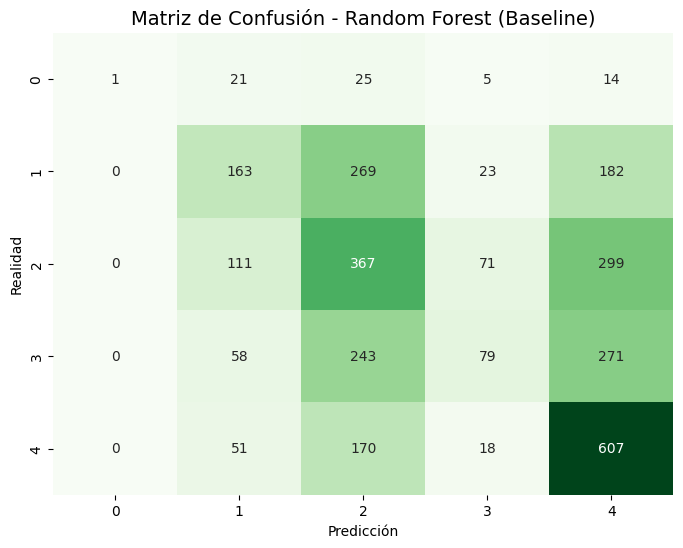

In [32]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.classification import (DecisionTreeClassifier, RandomForestClassifier, 
                                       MultilayerPerceptronClassifier, NaiveBayes, 
                                       LogisticRegression)
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

# ==============================================================================
# CONFIGURACIÓN
# ==============================================================================
GOLD_DIR = r"D:\BigData\Proyecto\gold"
SEED = 700
TARGET_COL = "AdoptionSpeed"

print("\n" + "="*80)
print(" CASO A: ML sobre datos ya seleccionados (Cargando desde Delta)")
print("="*80)

# ==============================================================================
# 1. CARGA DE DATOS YA PROCESADOS (Splits)
# ==============================================================================
# Cargamos directamente los splits que guardaste en el paso anterior
path_train = os.path.join(GOLD_DIR, "train_delta")
path_test = os.path.join(GOLD_DIR, "test_delta")

if not os.path.exists(path_train) or not os.path.exists(path_test):
    raise FileNotFoundError("¡No se encuentran los archivos delta! Ejecuta primero el bloque de Feature Selection y guardado.")

print(f"Cargando Train desde: {path_train}")
train_df = spark.read.format("delta").load(path_train)

print(f"Cargando Test desde: {path_test}")
test_df = spark.read.format("delta").load(path_test)

print(f"Registros Train: {train_df.count()} | Registros Test: {test_df.count()}")

# ==============================================================================
# 2. VECTORIZACIÓN (Obligatorio para Spark ML)
# ==============================================================================
# Aunque ya seleccionaste las variables, Spark necesita que:
# 1. Los textos (ej: "Golden Retriever") sean números (Indices).
# 2. Todas las columnas se unan en un solo vector llamado "features".

print("--- Preparando vector de características ---")

# A. Identificar dinámicamente qué columnas son texto (Categoricas) y cuáles numéricas
string_features = [f.name for f in train_df.schema.fields 
                   if f.dataType.simpleString() == 'string' and f.name != TARGET_COL]

# B. Crear Indexers para las categóricas
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in string_features]

# C. Definir inputs para el VectorAssembler
input_cols_assembler = []
for c in train_df.columns:
    if c == TARGET_COL: continue # El target no va en los features
    
    if c in string_features:
        input_cols_assembler.append(c + "_idx") # Usamos la versión transformada
    else:
        input_cols_assembler.append(c) # Usamos la numérica original

# D. Pipeline de Preprocesamiento
assembler = VectorAssembler(inputCols=input_cols_assembler, outputCol="features", handleInvalid="keep")
pipeline_prep = Pipeline(stages=indexers + [assembler])

# E. Ajustar y Transformar
prep_model = pipeline_prep.fit(train_df)
train_vec = prep_model.transform(train_df).select("features", TARGET_COL)
test_vec  = prep_model.transform(test_df).select("features", TARGET_COL)

# Cacheamos para velocidad
train_vec.cache()
test_vec.cache()

# ==============================================================================
# 3. DEFINICIÓN DE MODELOS Y GRILLAS
# ==============================================================================
input_layer_size = len(input_cols_assembler)
output_layer_size = 5 # Clases 0,1,2,3,4

# Modelos
dt = DecisionTreeClassifier(labelCol=TARGET_COL, featuresCol="features", seed=SEED, maxBins=500)
rf = RandomForestClassifier(labelCol=TARGET_COL, featuresCol="features", seed=SEED, maxBins=500)
mlp = MultilayerPerceptronClassifier(labelCol=TARGET_COL, featuresCol="features", seed=SEED, blockSize=128)
nb = NaiveBayes(labelCol=TARGET_COL, featuresCol="features", modelType="multinomial")
lr = LogisticRegression(labelCol=TARGET_COL, featuresCol="features", family="multinomial")

# Grillas (Ajusta según tu capacidad de cómputo)
grid_dt = ParamGridBuilder().addGrid(dt.maxDepth, [5, 10]).build()
grid_rf = ParamGridBuilder().addGrid(rf.numTrees, [50, 100]).addGrid(rf.maxDepth, [10]).build()
grid_mlp = ParamGridBuilder().addGrid(mlp.layers, [[input_layer_size, 32, 16, output_layer_size]])\
                             .addGrid(mlp.maxIter, [50]).build()
grid_nb = ParamGridBuilder().addGrid(nb.smoothing, [1.0]).build()
grid_lr = ParamGridBuilder().addGrid(lr.regParam, [0.1]).addGrid(lr.maxIter, [50]).build()

models_config = {
    "DecisionTree": (dt, grid_dt),
    "RandomForest": (rf, grid_rf),
    "MLP": (mlp, grid_mlp),
    "NaiveBayes": (nb, grid_nb),
    "LogisticRegression": (lr, grid_lr)
}

# ==============================================================================
# 4. EJECUCIÓN DEL TORNEO
# ==============================================================================
print(f"\n{'Modelo':20s} | Accuracy|F1-score |Precision| Recall")
print("-" * 80)

multi_eval = MulticlassClassificationEvaluator(labelCol=TARGET_COL, predictionCol="prediction")
metrics = [("accuracy", "Accuracy"), ("f1", "F1-score"), 
           ("weightedPrecision", "Precision (w)"), ("weightedRecall", "Recall (w)")]

model_preds = {}

for name, (estimator, param_grid) in models_config.items():
    try:
        # CrossValidator con 2 folds para pruebas rápidas
        cv = CrossValidator(estimator=estimator, estimatorParamMaps=param_grid,
                            evaluator=multi_eval.setMetricName("accuracy"),
                            numFolds=2, seed=SEED)

        cv_model = cv.fit(train_vec)
        best_model = cv_model.bestModel
        
        pred = best_model.transform(test_vec)
        model_preds[name] = pred
        
        results = {}
        for metric_key, label in metrics:
            results[metric_key] = multi_eval.setMetricName(metric_key).evaluate(pred)
        
        print(f"{name:20s} | {results['accuracy']:.3f}   | {results['f1']:.3f}   | " \
              f"{results['weightedPrecision']:.3f}   | {results['weightedRecall']:.3f}")
              
    except Exception as e:
        print(f"{name:20s} | FALLÓ: {str(e)[:50]}...")

# ==============================================================================
# 5. VISUALIZACIÓN (Random Forest)
# ==============================================================================
if "RandomForest" in model_preds:
    rf_preds = model_preds["RandomForest"]
    
    def get_rf_confusion_matrix(pred_df):
        cm = (pred_df
              .groupBy(TARGET_COL, "prediction")
              .agg(F.count(F.lit(1)).alias("count"))
              .toPandas()
              .pivot(index=TARGET_COL, columns="prediction", values="count")
              .fillna(0)
              .astype(int))
        
        # Aseguramos todas las clases
        classes = [0, 1, 2, 3, 4]
        cm = cm.reindex(index=classes, columns=classes, fill_value=0)
        return cm.values

    try:
        cm_rf = get_rf_confusion_matrix(rf_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False, 
                    xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
        plt.title("Matriz de Confusión - Random Forest (Baseline)", fontsize=14)
        plt.ylabel("Realidad")
        plt.xlabel("Predicción")
        plt.show()
    except Exception as e:
        print(f"Error graficando: {e}")

### ELIMINAR CATEGORIA 0 + OVERSAMPLING

In [33]:
from pyspark.ml.classification import (DecisionTreeClassifier, RandomForestClassifier, 
                                       MultilayerPerceptronClassifier, NaiveBayes, 
                                       LogisticRegression)
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col
from functools import reduce
import os

# ==============================================================================
# 3. EJECUCIÓN CASO B: SIN CLASE 0 + OVERSAMPLING + TORNEO TUNING
# ==============================================================================
print("\n" + "="*80)
print(" CASO B: Filtrando Clase 0 + Oversampling Real + Tuning de Modelos")
print("="*80)

# 1. CARGA DE DATOS OPTIMIZADOS
# Usamos la tabla maestra seleccionada por tu FeatureSelector
path_master_opt = os.path.join(GOLD_DIR, "gold_train_ready_delta")
df_opt = spark.read.format("delta").load(path_master_opt)

# 2. FILTRADO INICIAL (Quitar el ruido - Clase 0)
df_sin_ceros = df_opt.filter(col("AdoptionSpeed") != 0) \
                     .withColumn("label", col("AdoptionSpeed").cast("int"))

print(f"Total registros (sin clase 0): {df_sin_ceros.count()}")

# 3. SPLIT HONESTO (80/20)
# Importante: El split se hace ANTES del oversampling para evitar data leakage
train_real, test_real = df_sin_ceros.randomSplit([0.8, 0.2], seed=700)
print(f"Train original: {train_real.count()} | Test (Intocable): {test_real.count()}")

# 4. OVERSAMPLING (SOLO AL TRAIN)
print("Aplicando Oversampling al set de entrenamiento...")
class_counts = train_real.groupBy("label").count().collect()
conteo_dict = {row['label']: row['count'] for row in class_counts}
max_count = max(conteo_dict.values())

dfs_oversampled = []
for label, count in conteo_dict.items():
    ratio = max_count / count
    df_class = train_real.filter(col("label") == label)
    
    if ratio > 1.0:
        df_class = df_class.sample(withReplacement=True, fraction=ratio, seed=700)
    dfs_oversampled.append(df_class)

# Unimos todo para crear el set de entrenamiento final balanceado
train_balanced = reduce(lambda a, b: a.union(b), dfs_oversampled)
print(f"Train Balanceado final: {train_balanced.count()}")

# 5. PREPARACIÓN DE FEATURES (PIPELINE DINÁMICO)
target_col = "label"

# A. Identificar columnas String en el dataset balanceado
string_features = [f.name for f in train_balanced.schema.fields 
                   if f.dataType.simpleString() == 'string' and f.name not in ["AdoptionSpeed", "label"]]

# B. Crear Indexers
indexers = []
for c in string_features:
    indexers.append(StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep"))

# C. Definir columnas de entrada para el vector
input_cols_assembler = []
# Iteramos sobre las columnas del DF original para mantener el orden, excluyendo targets
for c in train_balanced.columns:
    if c in ["AdoptionSpeed", "label"]: continue
    
    if c in string_features:
        input_cols_assembler.append(c + "_idx")
    else:
        input_cols_assembler.append(c)

print(f"Features finales: {len(input_cols_assembler)}")

# D. Pipeline de Transformación
assembler = VectorAssembler(inputCols=input_cols_assembler, outputCol="features", handleInvalid="keep")
pipeline_prep = Pipeline(stages=indexers + [assembler])

# E. Ajustar y Transformar
# Ajustamos con el Train Balanceado
prep_model = pipeline_prep.fit(train_balanced)

train_vec = prep_model.transform(train_balanced).select("features", target_col)
test_vec  = prep_model.transform(test_real).select("features", target_col)

# Cacheamos
train_vec.cache()
test_vec.cache()

# ==============================================================================
# 6. DEFINICIÓN DE MODELOS Y TUNING
# ==============================================================================
input_layer_size = len(input_cols_assembler)
# Como quitamos la clase 0, las clases son 1,2,3,4. 
# El índice máximo es 4, así que necesitamos tamaño de salida 5 para que el índice 4 sea válido.
output_layer_size = 5 

dt = DecisionTreeClassifier(labelCol=target_col, featuresCol="features", seed=SEED, maxBins=500)
rf = RandomForestClassifier(labelCol=target_col, featuresCol="features", seed=SEED, maxBins=500)
mlp = MultilayerPerceptronClassifier(labelCol=target_col, featuresCol="features", seed=SEED, blockSize=128)
nb = NaiveBayes(labelCol=target_col, featuresCol="features", modelType="multinomial")
lr = LogisticRegression(labelCol=target_col, featuresCol="features", family="multinomial")

# Grillas (Iguales al caso anterior)
grid_dt = ParamGridBuilder().addGrid(dt.maxDepth, [5, 10]).build()
grid_rf = ParamGridBuilder().addGrid(rf.numTrees, [50, 100]).addGrid(rf.maxDepth, [5, 10]).build()
grid_mlp = ParamGridBuilder().addGrid(mlp.layers, [[input_layer_size, 32, 16, output_layer_size], 
                                                   [input_layer_size, 64, 32, output_layer_size]])\
                             .addGrid(mlp.maxIter, [50, 100]).build()
grid_nb = ParamGridBuilder().addGrid(nb.smoothing, [0.5, 1.0]).build()
grid_lr = ParamGridBuilder().addGrid(lr.regParam, [0.01, 0.1]).addGrid(lr.maxIter, [50, 100]).build()

models_config = {
    "DecisionTree": (dt, grid_dt),
    "RandomForest": (rf, grid_rf),
    "MLP": (mlp, grid_mlp),
    "NaiveBayes": (nb, grid_nb),
    "LogisticRegression": (lr, grid_lr)
}

# ==============================================================================
# 7. EJECUCIÓN DEL TORNEO (CORREGIDO: Guardando Predicciones)
# ==============================================================================
print(f"\n{'Modelo':20s} | Accuracy|F1-score |Precision| Recall")
print("-" * 80)

multi_eval = MulticlassClassificationEvaluator(labelCol=target_col, predictionCol="prediction")
metrics = [("accuracy", "Accuracy"), ("f1", "F1-score"), 
           ("weightedPrecision", "Precision (w)"), ("weightedRecall", "Recall (w)")]

# --- CORRECCIÓN: Inicializamos el diccionario para guardar predicciones ---
model_preds = {} 

for name, (estimator, param_grid) in models_config.items():
    try:
        # CrossValidator con 3 folds (o 2 si quieres que vaya más rápido)
        cv = CrossValidator(estimator=estimator, estimatorParamMaps=param_grid,
                            evaluator=multi_eval.setMetricName("accuracy"),
                            numFolds=3, seed=SEED)

        cv_model = cv.fit(train_vec)
        best_model = cv_model.bestModel
        
        # Predecir
        pred = best_model.transform(test_vec)
        
        #Guardamos la predicción en el diccionario ---
        model_preds[name] = pred 
        
        results = {}
        for metric_key, label in metrics:
            results[metric_key] = multi_eval.setMetricName(metric_key).evaluate(pred)
        
        print(f"{name:20s} | {results['accuracy']:.3f}   | {results['f1']:.3f}   | " \
              f"{results['weightedPrecision']:.3f}   | {results['weightedRecall']:.3f}")
              
    except Exception as e:
        print(f"{name:20s} | FALLÓ: {str(e)[:50]}...")


 CASO B: Filtrando Clase 0 + Oversampling Real + Tuning de Modelos
Total registros (sin clase 0): 14583
Train original: 11609 | Test (Intocable): 2974
Aplicando Oversampling al set de entrenamiento...
Train Balanceado final: 13157
Features finales: 19

Modelo               | Accuracy|F1-score |Precision| Recall
--------------------------------------------------------------------------------
DecisionTree         | 0.365   | 0.363   | 0.366   | 0.365
RandomForest         | 0.423   | 0.402   | 0.409   | 0.423
MLP                  | 0.378   | 0.362   | 0.366   | 0.378
NaiveBayes           | 0.186   | 0.124   | 0.177   | 0.186
LogisticRegression   | 0.340   | 0.327   | 0.346   | 0.340


c:\Users\GUSTAVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyspark\sql\pandas\conversion.py:95: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 11.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


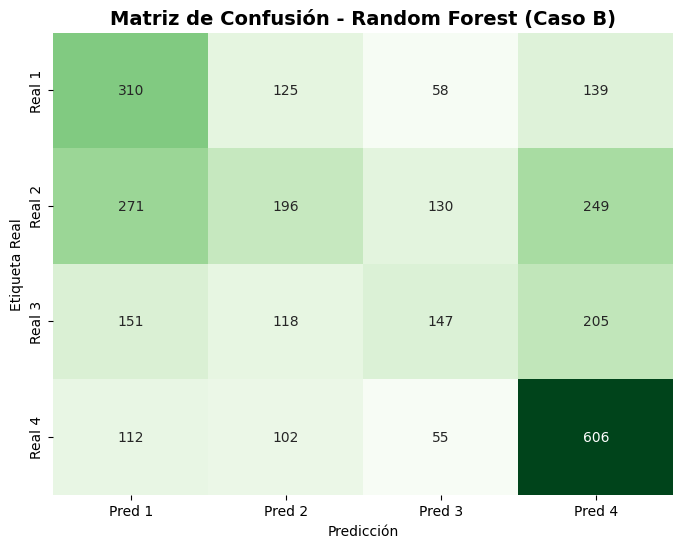

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F  # Usamos "F" para evitar conflictos de nombres

# ==============================================================================
# MATRIZ DE CONFUSIÓN SOLO PARA RANDOM FOREST
# ==============================================================================

# 1. Recuperar predicciones
if "RandomForest" in model_preds:
    rf_preds = model_preds["RandomForest"]

# 2. Función robusta para calcular la matriz
def get_rf_confusion_matrix(pred_df):
    # Detectar nombre real de la columna label
    label_col = "label"
    if label_col not in pred_df.columns:
        if "AdoptionSpeed" in pred_df.columns:
            label_col = "AdoptionSpeed"
            
    # Calcular conteos usando F.count y F.lit
    cm = (pred_df
          .groupBy(label_col, "prediction")
          .agg(F.count(F.lit(1)).alias("count")) 
          .toPandas()
          .pivot(index=label_col, columns="prediction", values="count")
          .fillna(0)
          .astype(int))
    
    # Asegurar que aparezcan las 4 clases (1, 2, 3, 4) del Caso B
    classes = [1, 2, 3, 4]
    cm = cm.reindex(index=classes, columns=classes, fill_value=0)
    return cm.values

# 3. Graficar
try:
    cm_rf = get_rf_confusion_matrix(rf_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False, 
                xticklabels=["Pred 1", "Pred 2", "Pred 3", "Pred 4"], 
                yticklabels=["Real 1", "Real 2", "Real 3", "Real 4"])

    plt.title("Matriz de Confusión - Random Forest (Caso B)", fontsize=14, fontweight='bold')
    plt.ylabel("Etiqueta Real")
    plt.xlabel("Predicción")
    plt.show()

except Exception as e:
    print(f"Error al generar la gráfica: {e}")

In [35]:
import os

# ==============================================================================
# GENERAR PREDICCIONES CON TEST GOLD (PRODUCCIÓN)
# ==============================================================================
print("--- Generando Predicciones para test_gold ---")

# 1. Cargar el Test Gold
# Este es el dataset que definiste en tu código, que ya tiene nulos rellenos pero no tiene Target.
path_test_gold = os.path.join(GOLD_DIR, "test_gold")
df_production = spark.read.format("delta").load(path_test_gold)

print(f"Total mascotas a predecir: {df_production.count()}")

# 2. Transformar los datos (Pipeline)
# IMPORTANTE: Usamos 'prep_model' que ya entrenaste en el Caso B.
# Este objeto recuerda cómo convertir "Golden Retriever" a números (índices).
try:
    # Transformamos las features (texto -> números -> vector)
    prod_vec = prep_model.transform(df_production)
    
except Exception as e:
    print("Error en la transformación. Verifica que prep_model esté en memoria.")
    print("Detalle:", e)

# 3. Generar Predicciones
# Usamos el mejor modelo que tengas disponible. 
# Si usaste CrossValidator, usa 'cv_model.bestModel'. 
# Si entrenaste un RF directo, usa 'model_b' o el que hayas guardado como campeón.

# Opción A: Usando el modelo extraído del CrossValidator (si corriste el código de Tuning)
if 'best_model' in locals():
    print("Usando el mejor modelo del Tuning (best_model)...")
    final_model = best_model
# Opción B: Usando el modelo simple (si corriste solo el entrenamiento simple)
elif 'model_b' in locals():
    print("Usando el modelo simple (model_b)...")
    final_model = model_b
else:
    # Si no encuentras ninguno, re-entrenamos el campeón rápido
    print("Re-entrenando modelo campeón (Random Forest 100 trees)...")
    from pyspark.ml.classification import RandomForestClassifier
    rf_champ = RandomForestClassifier(labelCol="label", featuresCol="features", 
                                      numTrees=100, maxDepth=10, seed=700, maxBins=500)
    final_model = rf_champ.fit(train_vec)

# Predecir
predictions_production = final_model.transform(prod_vec)

# 4. Seleccionar y Mostrar Resultados
# Generalmente para Kaggle/Negocio se necesita el ID y la Predicción
result_df = predictions_production.select("PetID", "prediction")

print("\nVista previa de las predicciones:")
result_df.show(10)

# 5. Guardar Resultados (Opcional)
output_path = os.path.join(GOLD_DIR, "predicciones_finales")
result_df.write.format("delta").mode("overwrite").save(output_path)
print(f"Predicciones guardadas en: {output_path}")

# Si quieres guardarlo en CSV para compartir:
# result_df.write.format("csv").mode("overwrite").option("header", "true").save(output_path + "_csv")

--- Generando Predicciones para test_gold ---
Total mascotas a predecir: 3972
Usando el mejor modelo del Tuning (best_model)...

Vista previa de las predicciones:
+---------+----------+
|    PetID|prediction|
+---------+----------+
|000aa306a|       4.0|
|001630d8d|       4.0|
|002089611|       4.0|
|002efc654|       4.0|
|0061e61ce|       4.0|
|0070b950a|       4.0|
|007311a1a|       4.0|
|009a75a42|       4.0|
|00c8a5254|       4.0|
|00cd4914c|       4.0|
+---------+----------+
only showing top 10 rows
Predicciones guardadas en: D:\BigData\Proyecto\gold\predicciones_finales


In [36]:
# Cargar las predicciones que acabas de generar
df_preds = spark.read.format("delta").load(r"D:\BigData\Proyecto\gold\predicciones_finales")

print("Distribución de las Predicciones:")
df_preds.groupBy("prediction").count().orderBy("prediction").show()

Distribución de las Predicciones:
+----------+-----+
|prediction|count|
+----------+-----+
|       1.0|  116|
|       3.0|   76|
|       4.0| 3780|
+----------+-----+

